In [1]:
print('test')

test


### 참고 : 모델	입력 형태	출력 형태
| 모델 | 입력 형태 | 출력 형태 (회귀 예) |
|---|---|---|
| **MLP** | **2차원** `(샘플, feature)` | **2차원** `(샘플, 출력)` |
| **RNN** | **3차원** `(샘플, timestep, feature)` | **보통 2차원** `(샘플, 출력)` |
| **LSTM** | **3차원** `(샘플, timestep, feature)` | **보통 2차원** `(샘플, 출력)` |
| **GRU** | **3차원** `(샘플, timestep, feature)` | **보통 2차원** `(샘플, 출력)` |

### 숫자 예측 모델(LSTM)

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
# 데이터 생성(랜덤 숫자 시퀀스)
data = np.array([i for i in range(1, 21)])
timesteps = 3       # sequence length와 같은 개념

In [8]:
x_data = []
y_data = []

In [9]:
# 타임스텝에 따라 입력 데이터와 출력 데이터 생성
for i in range(len(data)-timesteps):
    x_data.append(data[i : i + timesteps])  # 입력
    y_data.append(data[i + timesteps])    # 출력
    
x_data = np.array(x_data).reshape(-1, timesteps, 1)     # (샘플 수, 타임스텝, 피처 수)
y_data = np.array(y_data)   # 출력값

In [12]:
# LSTM 모델 정의
model = Sequential([
    LSTM(10, input_shape=(timesteps, 1)),  # LSTM 레이어 (유닛: 10)
    Dense(1)    # 출력 레이어
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam', loss='mse')

In [15]:
# 모델 학습
model.fit(x_data, y_data, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 153.6894
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 153.5191
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 153.3495
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 153.1808
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 153.0130
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 152.8459
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 152.6796
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 152.5141
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 152.3493
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 152.1852
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 152.0217
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 151.8589
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 151.6966
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 151.5349
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 

In [16]:
# 예측 테스트
test_input = np.array([18, 19, 20]).reshape(1, timesteps, 1)
predicted_value = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


In [18]:
# 결과 출력
# flatten함수 : [[[18],[19],[20]]] --> [18,19,20]
print("입력 데이터:", test_input.flatten()) 
print("예측 값:", model.predict(test_input))


입력 데이터: [18 19 20]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
예측 값: [[1.220035]]


### 기온예측 모델(RNN)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [20]:
# 데이터 로드
file_path = "../dataset/jena_climate_2009.csv"
data = pd.read_csv(file_path)

In [21]:
# Date Time: 관측 날짜 및 시간. p (mbar): 기압. T (degC): 기온, Tpot (K): 잠재온도
data.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [22]:
data.shape

(21743, 15)

In [23]:
# T (digC) : 기온
temperature = data['T (degC)'].values

In [24]:
# 데이터 전처리
scaler = MinMaxScaler(feature_range=(0, 1))     # 정규화
scaled_data = scaler.fit_transform(temperature.reshape(-1, 1))

In [25]:
# 데이터셋 생성 함수 : look_back(sequence_length와 같은 의미)
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i : i+look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [26]:
look_back = 60      # 과거 60분 데이터를 기반으로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))      # RNN 입력 형태

In [27]:
X.shape

(21683, 60, 1)

In [28]:
# 데이터 분리
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [29]:
# RNN 모델 구성
model = Sequential([
    # 50(뉴런 즉 메모리유닛수), return_sequence=False(마지막시점 출력만 반환)
    SimpleRNN(50, return_sequences=False, input_shape=(X.shape[1], 1)), 
    Dense(1)
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [31]:
# 모델 학습
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0026 - val_loss: 6.0752e-04
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.1690e-04 - val_loss: 2.6255e-04
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.6023e-04 - val_loss: 1.5715e-04
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.1721e-04 - val_loss: 1.9507e-04
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 9.5809e-05 - val_loss: 1.6146e-04
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.0491e-05 - val_loss: 1.1610e-04
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 6.2072e-05 - val_loss: 1.1988e-04
Epoch 8/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.9636e-05 - val_loss: 1.0639e-04
Epoch 9/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.4515e-05 - val_loss: 8.8238e-05
Epoch 10/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.2004e-05 - val_loss: 8.6007e-05
Epoch 11/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.

In [32]:
# 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)     # 정규화 복원

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [33]:
# 실제 값 복원
actual_values = scaler.inverse_transform(y_test.reshape(-1, 1))

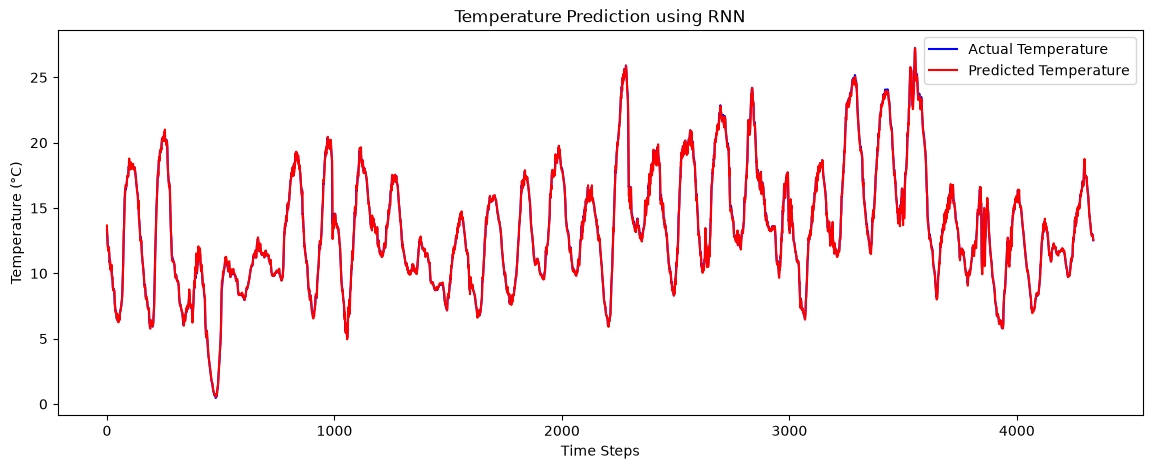

In [34]:
# 6. 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_values, label="Actual Temperature", color='blue')
plt.plot(predictions, label="Predicted Temperature", color='red')
plt.title('Temperature Prediction using RNN')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

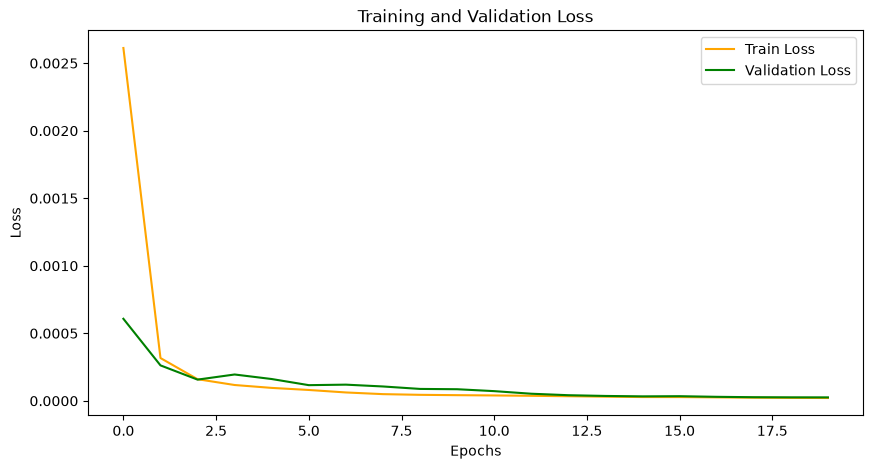

In [35]:
# 7. 학습 손실 시각화
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 주가예측 모델(LSTM)

In [36]:
# 증권 데이터 수집 라이브러리 설치 : pip install yfinance
# 한글 폴더는 에러가 나기 때문에 영문으로 변경
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [42]:
# 데이터 수집
ticker = "AAPL"     # 예: 애플 주식
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
data = data[['Close']]      # 종가만 사용

[*********************100%***********************]  1 of 1 completed


In [43]:
data.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,24.171755
2015-01-05,23.490799
2015-01-06,23.493013
2015-01-07,23.822435
2015-01-08,24.737751


In [44]:
# 데이터 전처리
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [45]:
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [46]:
look_back = 60
X, y = create_dataset(scaled_data, look_back)
# LSTM 입력 형태 (샘플수, 시퀀스 길이, 피처수)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [48]:
# 모델 구성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)),  # input_shape(시퀀스 길이, 피처수)
    LSTM(32),
    Dense(1)
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [50]:
# 모델 학습
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [51]:
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 9.7024e-04 - val_loss: 0.0026
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0035 - val_loss: 0.0023
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0023 - val_loss: 0.0081
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.0477e-04 - val_loss: 0.0011
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 7.3386e-04 - val_loss: 0.0015
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.8328e-04 - val_loss: 0.0011
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3.4890e-04 - val_loss: 0.0011
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 3.4746e-04 - val_loss: 9.2047e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.4705e-04 - val_loss: 8.8323e-04
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 3.3716e-04 - val_loss: 8.6409e-04
Epoch 12/20
56/56 ━

In [52]:
# 5. 예측 및 시각화
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))  # 2차원 배열로 표시 (샘플수, 1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [53]:
# 실제 값 복원
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

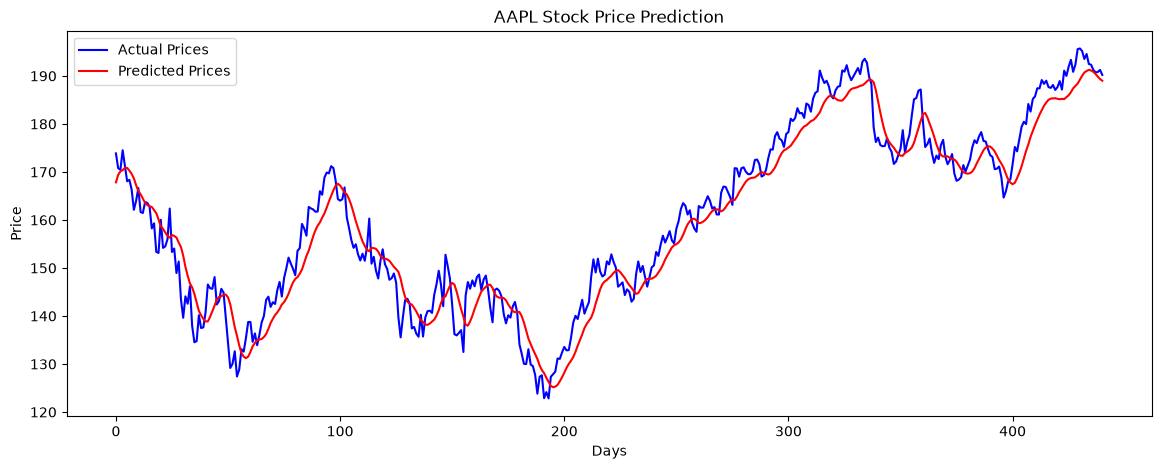

In [54]:
# 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label="Actual Prices", color='blue')
plt.plot(predictions, label="Predicted Prices", color='red')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

### 항공기 탑승객 수요 예측(LSTM)

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [56]:
# 데이터 불러오기
data_path = '../dataset/airline.csv'
df = pd.read_csv(data_path)

In [57]:
df.head()

,date,count
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [58]:
# 날짜(date)와 탑승객 수(count) 열의 이름 설정 및 변환
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

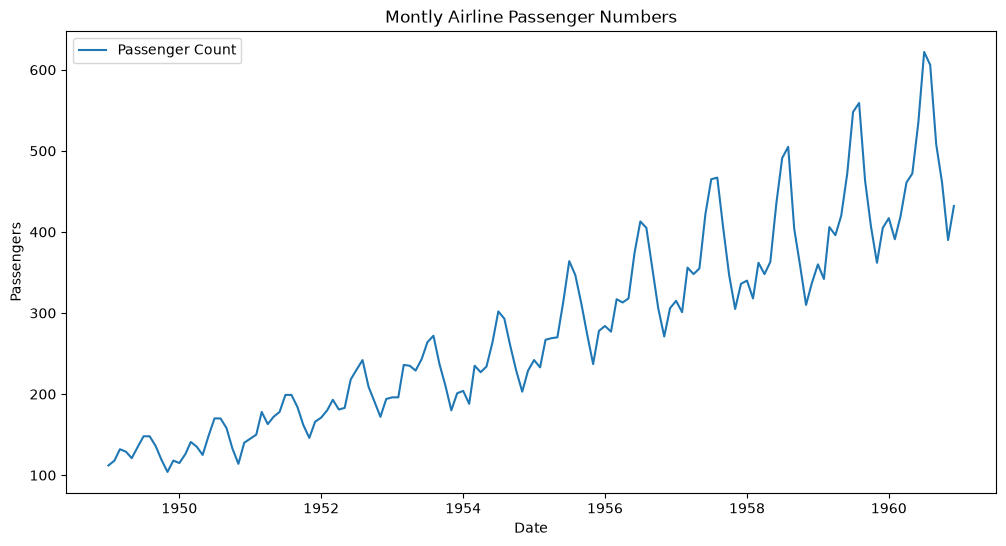

In [59]:
# 데이터 시각화 
plt.figure(figsize=(12, 6))
plt.plot(df['count'], label='Passenger Count')
plt.title('Montly Airline Passenger Numbers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [60]:
# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['count']])

In [62]:
# 데이터셋 분리
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [63]:
# 시계열 데이터셋 생성 함수
def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

In [64]:
time_step = 12      # 12개월 단위로 예측
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [65]:
# LSTM 입력에 맞게 데이터 형태 변경
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [66]:
# LSTM 모델 생성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(32, return_sequences=False),
    Dense(16), 
    Dense(1)
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

In [68]:
# 모델 학습
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1, shuffle=False)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 253ms/step - loss: 0.0919 - val_loss: 0.2679
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0231 - val_loss: 0.0664
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0099 - val_loss: 0.0230
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0246 - val_loss: 0.0230
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0162 - val_loss: 0.0387
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0115 - val_loss: 0.0598
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0109 - val_loss: 0.0574
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0090 - val_loss: 0.0401
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0077 - val_loss: 0.0273
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0084 - val_loss: 0.0245
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0083 - val_loss: 0.0256
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0073 - val_loss: 0.0286


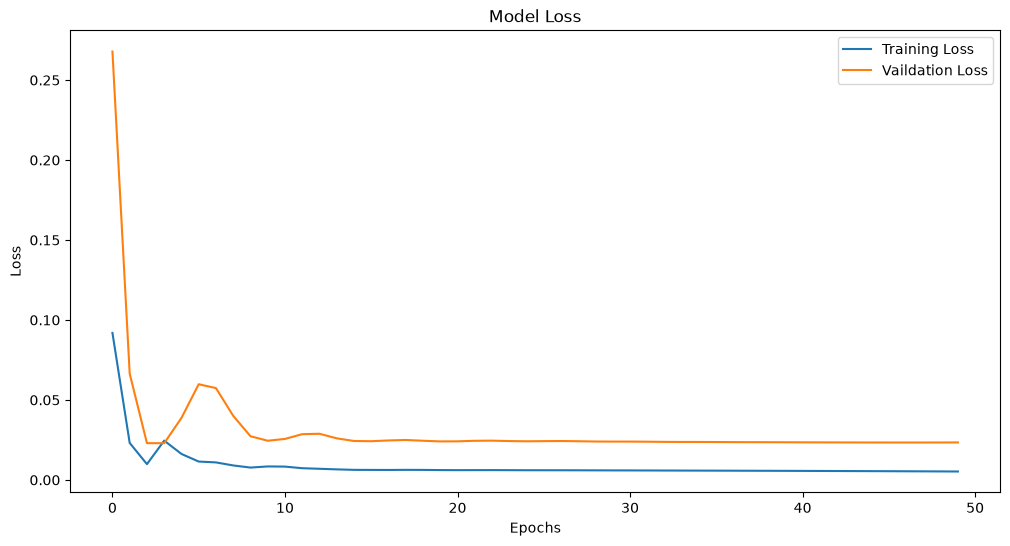

In [69]:
# 학습 과정 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Vaildation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [70]:
# 테스트 데이터 예측
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [71]:
# 예측값 역정규화
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

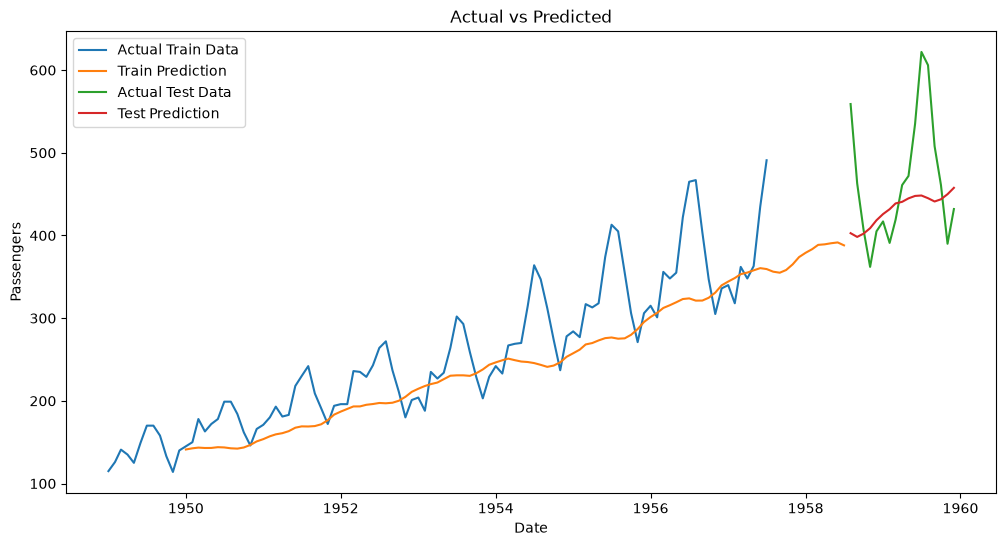

In [72]:
# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index[:len(y_train)], y_train, label='Actual Train Data')
plt.plot(df.index[time_step:len(train_predict) + time_step], train_predict, label='Train Prediction')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], y_test, label='Actual Test Data')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], test_predict, label='Test Prediction')
plt.title('Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()

### 자전거 대여량 예측(MLPRegressor + 로그변환 + 잔차분석)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import scipy.stats as stats

# [Tip] 주피터 노트북의 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

In [9]:
dataset_path = '../dataset/'

# copy()를 사용하여 원본 파일 로딩 시 메모리 간섭 차단
train_data = pd.read_csv(dataset_path + 'train.csv').copy()
test_data = pd.read_csv(dataset_path+ 'test.csv').copy()

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")

Train shape: (10886, 12)
Test shape: (6493, 9)


In [10]:
# 2. 전처리 (시계열 특성 반영)
def preprocess_data(data_raw):
    # [개선] 함수 내부에서 원본을 건드리지 않도록 복사본 생성
    data = data_raw.copy()

    # 2-1. 날짜 변환
    data['datetime'] = pd.to_datetime(data['datetime'])

    # 2-2. [중요] 시계열 데이터를 시간 순서대로 정렬 (과거->미래)
    data = data.sort_values('datetime')

    # 정렬 후 인덱스가 뒤섞여 있으면 나중에 iloc/loc 사용 시
    # 꼬일 수 있으므로 인덱스를 0부터 다시 부여 (메모리 꼬임 방지)
    data = data.reset_index(drop=True)

    # 2-3. Feature Engineering (날짜 쪼개기)
    data['hour'] = data['datetime'].dt.hour
    data['day'] = data['datetime'].dt.day
    data['month'] = data['datetime'].dt.month
    data['year'] = data['datetime'].dt.year
    data['weekday'] = data['datetime'].dt.weekday

    # 2-4. 불필요 컬럼 제거
    drop_cols = ['datetime', 'casual', 'registered']
    data = data.drop(drop_cols, axis=1, errors='ignore')

    return data

In [11]:
train  = preprocess_data(train_data)

In [12]:
train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,year,weekday
0,1,0,0,1,9.84,14.395,81,0.0,16,0,1,1,2011,5
1,1,0,0,1,9.02,13.635,80,0.0,40,1,1,1,2011,5
2,1,0,0,1,9.02,13.635,80,0.0,32,2,1,1,2011,5
3,1,0,0,1,9.84,14.395,75,0.0,13,3,1,1,2011,5
4,1,0,0,1,9.84,14.395,75,0.0,1,4,1,1,2011,5


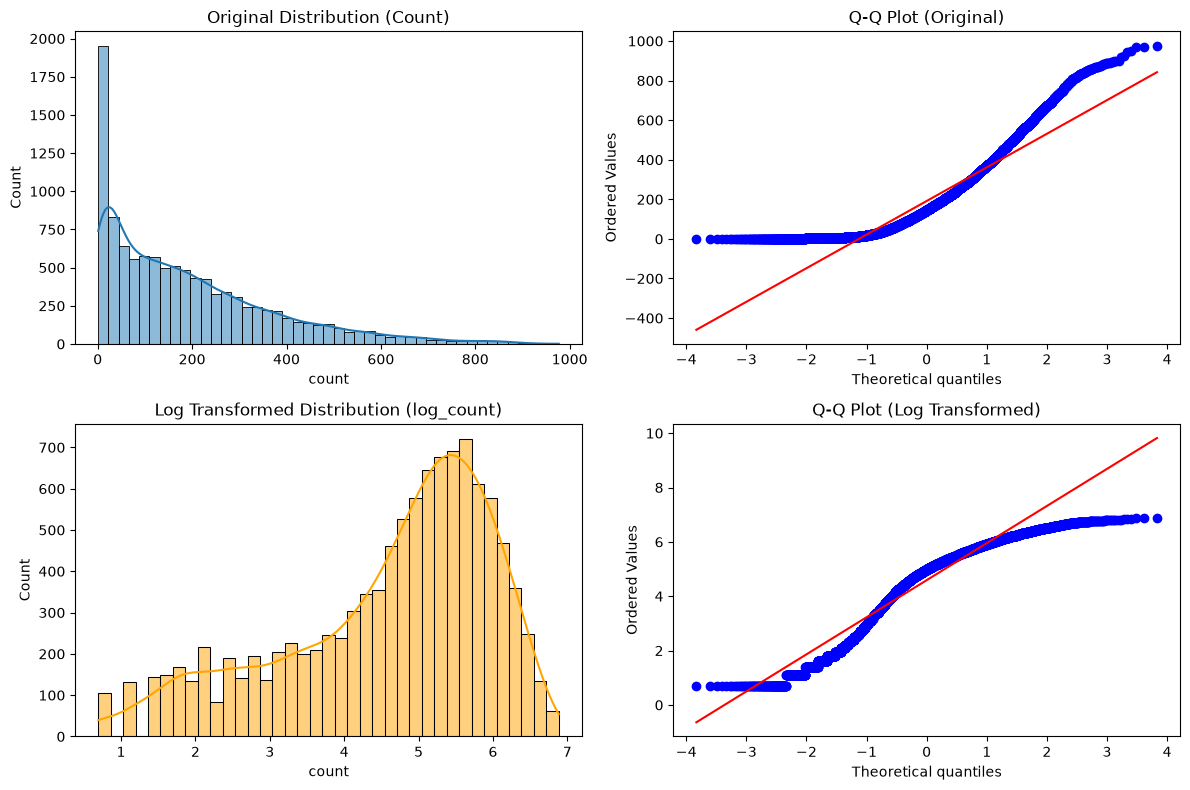

In [15]:
plt.figure(figsize=(12, 8))

# 3-1 변환 전 (Original)
plt.subplot(2, 2, 1)
sns.histplot(train['count'], kde=True)
plt.title("Original Distribution (Count)")

plt.subplot(2, 2, 2)
stats.probplot(train['count'], dist='norm', plot=plt)
plt.title("Q-Q Plot (Original)")

# 3-2 변환 후 (Log Transform)
# [주의] 여기서 만든 log_count는 시각화용 임시 변후로만 사용(train 원본에 넣지 않음)
log_count_temp = np.log1p(train['count'])

plt.subplot(2, 2, 3)
sns.histplot(log_count_temp, kde=True, color='orange')
plt.title("Log Transformed Distribution (log_count)")

plt.subplot(2, 2, 4)
stats.probplot(log_count_temp, dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed)")

plt.tight_layout()
plt.show()

In [16]:
# 4. 데이터셋 분리 및 정규화
# 4-1. Feature(X)와 Target(y) 정의
# 시각화에서 log_count를 train에 추가하지 않았으므로, drop할 때 'count'만 빼면 됨
X = train.drop(['count'], axis=1).copy()
y = train['count'].values.copy()

# 4-2 데이터 정규화
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 4-3 Train / Validation 분리(시계열 Shuffle=False)
train_size = int(len(X_scaled) * 0.8)

X_train = X_scaled[:train_size]
X_val = X_scaled[train_size:]
y_val_raw = y[train_size:] # 검증용 정답 (공통)

print(f"Train samples: {len(X_train)}, Validation samples: {len(X_val)}")

Train samples: 8708, Validation samples: 2178


In [17]:
# 5. Case 1: 로그 변환 미적용 학습
print("\n[Case 1] 로그 변환 미적용 학습")
y_train_raw = y[:train_size]

model_raw = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model_raw.fit(X_train, y_train_raw)

pred_raw = model_raw.predict(X_val)
pred_raw = np.maximum(pred_raw, 0) # 음수 보정

rmse_raw = np.sqrt(mean_squared_error(y_val_raw, pred_raw))


[Case 1] 로그 변환 미적용 학습


In [18]:
# 6. Case 2: 로그 변환 적용 학습
# --------------------------------------------------------------------------------
print("\n[Case 2] 로그 변환 적용 학습")

# 학습용 정답 로그 변환 (log1p)
y_train_log = np.log1p(y[:train_size])

model_log = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model_log.fit(X_train, y_train_log)

pred_log_scaled = model_log.predict(X_val)

# 복원 (expm1)
pred_restored = np.expm1(pred_log_scaled)
pred_restored = np.maximum(pred_restored, 0)

rmse_log = np.sqrt(mean_squared_error(y_val_raw, pred_restored))


[Case 2] 로그 변환 적용 학습


In [19]:
# 7. 결과 비교
# --------------------------------------------------------------------------------
print("\n" + "="*50)
print(f"1. 로그 변환 미적용 RMSE : {rmse_raw:.4f}")
print(f"2. 로그 변환 적용 RMSE   : {rmse_log:.4f}")
print(f"-> 성능 개선 효과          : {rmse_raw - rmse_log:.4f}")
print("="*50)


1. 로그 변환 미적용 RMSE : 116.2022
2. 로그 변환 적용 RMSE   : 108.6387
-> 성능 개선 효과          : 7.5635


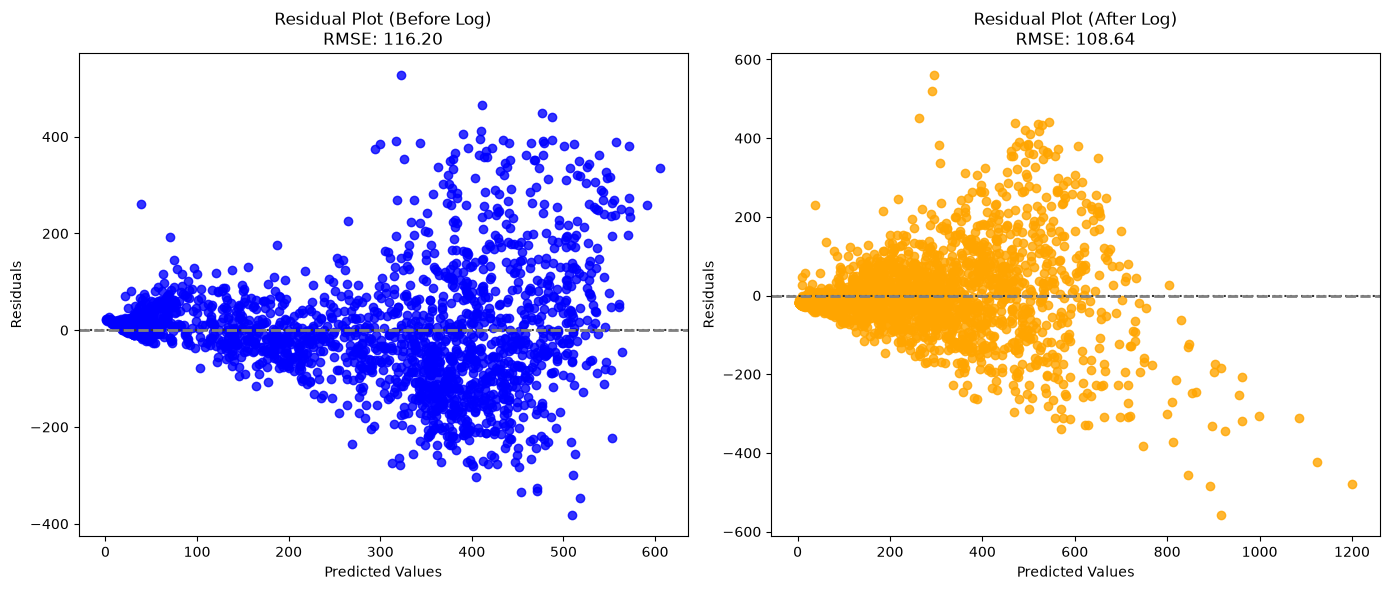

In [ ]:
# 8. 시각화 (Log 변환 전/후 잔차 비교)
# 잔차(Residuals) 계산: 실제값 - 예측값
residuals_raw = y_val_raw - pred_raw          # 로그 변환 전 잔차
residuals_log = y_val_raw - pred_restored     # 로그 변환 후 잔차 (복원된 값 기준)

plt.figure(figsize=(14, 6))

# 1. 로그 변환 이전 (Before Log)
plt.subplot(1, 2, 1)
# lowess=False로 설정하여 에러 방지
sns.residplot(x=pred_raw, y=residuals_raw, lowess=False, color='blue')  # lowess=False : 잔차 추세를 보여주는 부드러운 곡선 표현 여부
plt.axhline(0, color='gray', linestyle='--', linewidth=2) # 기준선 (0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot (Before Log)\nRMSE: {rmse_raw:.2f}")

# 2. 로그 변환 이후 (After Log)
plt.subplot(1, 2, 2)
# lowess=False로 설정하여 에러 방지
sns.residplot(x=pred_restored, y=residuals_log, lowess=False, color='orange')
plt.axhline(0, color='gray', linestyle='--', linewidth=2) # 기준선 (0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot (After Log)\nRMSE: {rmse_log:.2f}")

plt.tight_layout()
plt.show()

### LSTM, BiLSTM, GRU 비교

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
file_path = '../dataset/seoul_pm10.csv'

df = pd.read_csv(file_path, encoding='cp949')

In [24]:
df.head()

,date,area,pm10,pm2.5
0,2022-12-31 23:00,강남구,57.0,44.0
1,2022-12-31 23:00,강동구,68.0,55.0
2,2022-12-31 23:00,강북구,59.0,42.0
3,2022-12-31 23:00,강서구,62.0,40.0
4,2022-12-31 23:00,관악구,57.0,38.0


In [25]:
# 강남구 데이터만 필터링
target_area = '강남구'
df_gangnam = df[df['area'] == target_area].copy()

In [27]:
# 시간 순서 정렬 (시계열 예측 필수)
df_gangnam['date'] = pd.to_datetime(df_gangnam['date'])
df_gangnam = df_gangnam.sort_values('date')

# PM10 컬럼의 빈 값을 시간 흐름에 따라 부드럽게 채워줌 (보간법)
df_gangnam['pm10'] = df_gangnam['pm10'].interpolate(method='linear')

print(f"[{target_area}] 데이터 추출 완료: 총 {len(df_gangnam)}개 샘플")

[강남구] 데이터 추출 완료: 총 8760개 샘플


In [28]:
# 학습에 사용할 타겟 컬럼 선택 (PM10)
data = df_gangnam['pm10'].values.reshape(-1, 1)

In [29]:
# 2. 데이터 전처리 (스케일링 및 시퀀스 생성)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=24):
    X, Y = [], []
    for i in range(len(dataset) - time_step -1):
        a = dataset[i:(i + time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

In [31]:
# 하이퍼 파라미터
time_step = 24
train_size = int(len(scaled_data) * 0.8)
test_size = len(scaled_data) - train_size

train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:len(scaled_data), :]

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [33]:
# 모델 입력 차원 변환: [Samples, Time Steps, Features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [41]:
# 3. 모델 정의 및 학습 함수
def train_and_predict(model_name):
    model = Sequential()

    # ---------------------------------------------------------
    # 1. RNN Layer (Feature Extraction)
    # ---------------------------------------------------------
    # 뉴런 수를 64로 늘려 더 많은 특징을 잡아내도록 설정
    if model_name == 'LSTM':
        model.add(LSTM(64, return_sequences=False, input_shape=(time_step, 1)))
    elif model_name == 'BiLSTM':
        model.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=(time_step, 1)))
    elif model_name == 'GRU':
        model.add(GRU(64, return_sequences=False, input_shape=(time_step, 1)))

    # RNN 층 직후 과적합 방지 및 학습 안정화
    model.add(BatchNormalization()) # 데이터 분포 정규화
    model.add(Dropout(0.3))         # 뉴런 30% 비활성화


    # ---------------------------------------------------------
    # 2. Dense Layers (Fully Connected) - 계층적 구조화
    # ---------------------------------------------------------
    # 구조: 32 -> 16 (점진적으로 줄여나가며 특징 압축)

    # Hidden Layer 1 (32)
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2)) # 20% 비활성화

    # Hidden Layer 2 (16)
    model.add(Dense(16, activation='relu'))
    # 마지막 층 전에는 보통 Dropout을 약하게 하거나 생략하기도 함


    # ---------------------------------------------------------
    # 3. Output Layer
    # ---------------------------------------------------------
    model.add(Dense(1)) # 회귀 예측이므로 활성화 함수 없음 (Linear)

    # 컴파일
    model.compile(optimizer='adam', loss='mean_squared_error')


    # ---------------------------------------------------------
    # 4. Early Stopping 설정
    # ---------------------------------------------------------
    # val_loss가 10번(patience) 동안 개선되지 않으면 학습 조기 종료
    # restore_best_weights=True: 학습이 멈췄을 때, 가장 성능이 좋았던 시점의 가중치로 복구
    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

    print(f"\nTraining {model_name} for {target_area}...")

    # 학습 시작
    # EarlyStopping에 의해 조기 종료될 수 있음
    model.fit(X_train, y_train,
              validation_data=(X_test, y_test),
              epochs=20,
              batch_size=32,
              callbacks=[early_stop],
              verbose=1)

    # 예측 수행
    pred = model.predict(X_test)

    # 원래 스케일로 복원
    pred_inv = scaler.inverse_transform(pred)
    y_test_inv = scaler.inverse_transform([y_test])

    # RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_test_inv[0], pred_inv[:,0]))

    return rmse, pred_inv

In [42]:
# 4. 성능 비교 및 시각화
models = ['LSTM', 'BiLSTM', 'GRU']
results = {}
predictions = {}

for m in models:
    rmse, pred = train_and_predict(m)
    results[m] = rmse
    predictions[m] = pred
    print(f">> {m} RMSE: {rmse:.4f}")


Training LSTM for 강남구...
Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.3170 - val_loss: 0.0168
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0761 - val_loss: 0.0211
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0458 - val_loss: 0.0208
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0265 - val_loss: 0.0145
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0193 - val_loss: 0.0126
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0146 - val_loss: 0.0070
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0103 - val_loss: 0.0053
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0079 - val_loss: 0.0054
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0045 - val_loss: 0.0032
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0034 - val_loss: 0.0024
Epoch 12/20
219/219 ━

In [43]:
# 결과 요약
best_model = min(results, key=results.get)
print("\n" + "="*40)
print(f"[{target_area} 미세먼지 예측 결과]")
print(f"가장 성능이 좋은 모델: {best_model} (RMSE: {results[best_model]:.4f})")
print("="*40)


[강남구 미세먼지 예측 결과]
가장 성능이 좋은 모델: GRU (RMSE: 10.1589)


### 타이타닉 생존자 예측 예제(MLP)

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [47]:
plt.rcParams['font.family'] = 'Malgun Gothic'

In [48]:
train_df = pd.read_csv("../dataset/train_titanic.csv")
test_df = pd.read_csv("../dataset/test_titanic.csv")

In [49]:
# 1.1 전처리 전 데이터 확인
print("=== 전처리 전 데이터 (train_df) ===")
print(train_df.head())
print("\n=== 데이터 기본 정보 ===")
print(train_df.info())
print("\n=== 결측값 수 ===")
print(train_df.isnull().sum())

=== 전처리 전 데이터 (train_df) ===
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]

=== 데이터 기본 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str

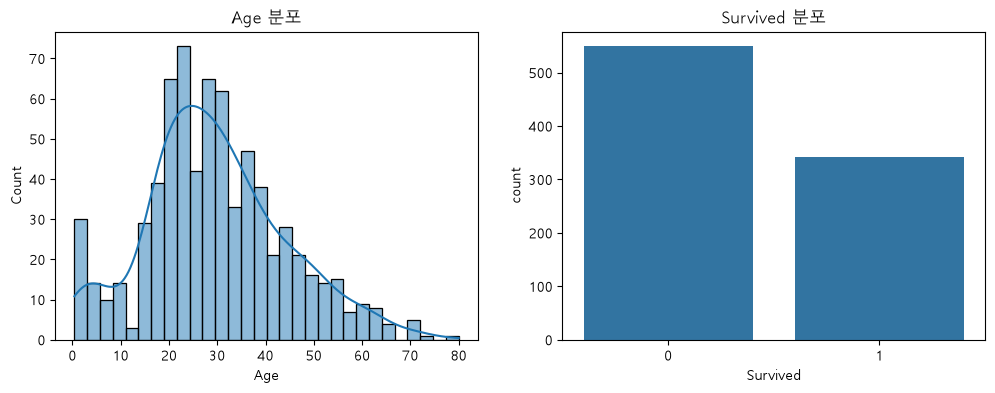

In [51]:
# 주요 특성 분포 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(train_df['Age'].dropna(), bins=30, kde=True)
plt.title('Age 분포')
plt.subplot(1, 2, 2)
sns.countplot(x='Survived', data=train_df)
plt.title('Survived 분포')
plt.show()

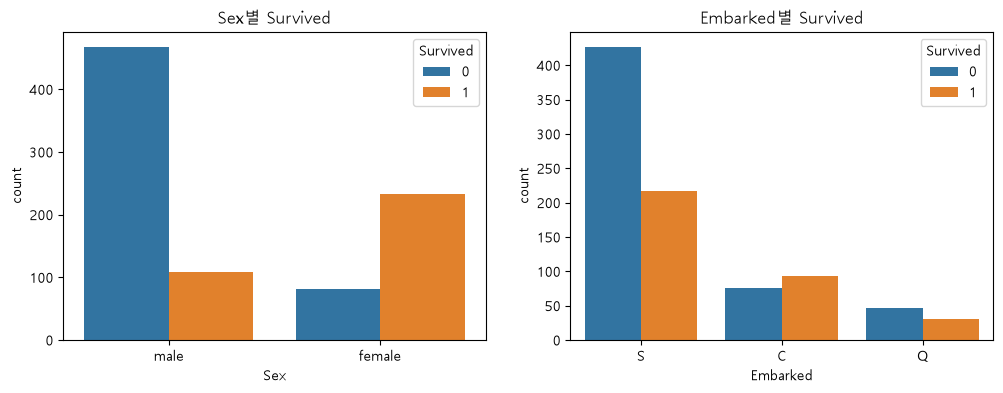

In [54]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x="Sex", hue='Survived', data=train_df)
plt.title("Sex별 Survived")
plt.subplot(1, 2, 2)
sns.countplot(x="Embarked", hue='Survived', data=train_df)
plt.title('Embarked별 Survived')
plt.show()

In [55]:
# 데이터 전처리
# 결측값 처리
train_df = train_df.assign(Age=train_df['Age'].fillna(train_df['Age'].median()))
test_df = test_df.assign(Age=test_df['Age'].fillna(test_df['Age'].median()))
train_df = train_df.assign(Embarked=train_df['Embarked'].fillna(train_df['Embarked'].mode()))
test_df = test_df.assign(Fare=test_df['Fare'].fillna(test_df['Fare'].median()))

In [56]:
# 특징 선택
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X_train = train_df[features]
y_train = train_df['Survived']
X_test = test_df[features]

In [57]:
# 원 핫 인코딩
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_features_train = ohe.fit_transform(X_train[['Sex', 'Embarked']])
cat_features_name = ohe.get_feature_names_out(['Sex', 'Embarked'])
cat_features_test = ohe.transform(X_test[['Sex', 'Embarked']])

In [58]:
# 연속형 데이터
num_features_train = X_train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
num_features_test = X_test[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
scaler = StandardScaler()
num_features_train_scaled = scaler.fit_transform(num_features_train)
num_features_test_scaled = scaler.transform(num_features_test)

In [60]:
# 데이터 결합
X_train_combined = np.hstack([num_features_train_scaled, cat_features_train])
X_test_combined = np.hstack([num_features_test_scaled, cat_features_test])

In [61]:
# 원 핫 인코딩 후 데이터 확인
X_train_combined_df = pd.DataFrame(X_train_combined, columns=list(num_features_train.columns) + list(cat_features_name))
print("\n=== 원핫 인코딩 후 데이터 (train) ===")
print(X_train_combined_df.head())
print("\n=== 원핫 인코딩 후 특성 수 ===")
print(f"특성 수: {X_train_combined.shape[1]}")


=== 원핫 인코딩 후 데이터 (train) ===
     Pclass       Age     SibSp  ...  Embarked_Q  Embarked_S  Embarked_nan
0  0.827377 -0.565736  0.432793  ...         0.0         1.0           0.0
1 -1.566107  0.663861  0.432793  ...         0.0         0.0           0.0
2  0.827377 -0.258337 -0.474545  ...         0.0         1.0           0.0
3 -1.566107  0.433312  0.432793  ...         0.0         1.0           0.0
4  0.827377  0.433312 -0.474545  ...         0.0         1.0           0.0

[5 rows x 11 columns]

=== 원핫 인코딩 후 특성 수 ===
특성 수: 11


In [62]:
# PCA 적용
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_combined)
X_test_pca = pca.transform(X_test_combined)

In [ ]:
# PCA 적용 후 데이터 확인
print("\n=== PCA 적용 후 데이터 (train) ===")
print(pd.DataFrame(X_train_pca).head())
print("\n=== PCA 후 특성 수 ===")
print(f"특성 수: {X_train_pca.shape[1]}")
print("\n=== PCA 설명된 분산 비율 ===")
print(pca.explained_variance_ratio_)


=== PCA 적용 후 데이터 (train) ===
          0         1         2         3         4         5         6
0  1.190836  0.188753 -0.111021  0.659448 -0.292553 -0.074324  0.187965
1 -1.931434 -0.278026 -0.259883  0.477729  1.115314  0.271742 -0.679617
2  0.952526 -0.286680 -0.245364 -0.375315  0.726082  0.447876  0.661665
3 -1.476783 -0.216006 -0.097334  0.492440  1.122157 -0.502989  0.439579
4  0.882371 -0.796783  0.416589  0.052967 -0.448855  0.198879  0.284746

=== PCA 후 특성 수 ===
특성 수: 7

=== PCA 설명된 분산 비율 ===
[0.29342163 0.28186552 0.12493901 0.1013185  0.06906285 0.06540957
 0.04683363]


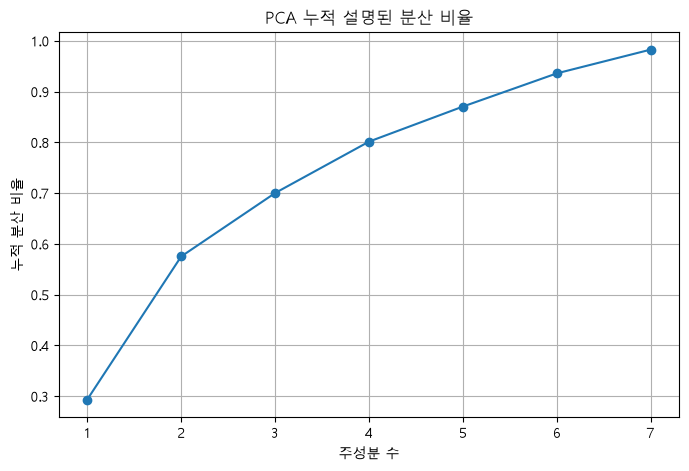

In [64]:
# PCA 설명된 분산 비율 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('PCA 누적 설명된 분산 비율')
plt.xlabel('주성분 수')
plt.ylabel('누적 분산 비율')
plt.grid(True)
plt.show()

In [65]:
# MLP 모델 구성
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [66]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [67]:
# 학습
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train_pca, y_train, epochs=50, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4831 - loss: 0.7268 - val_accuracy: 0.7318 - val_loss: 0.6689
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6292 - loss: 0.6721 - val_accuracy: 0.7598 - val_loss: 0.6309
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6657 - loss: 0.6398 - val_accuracy: 0.7989 - val_loss: 0.5976
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6966 - loss: 0.6198 - val_accuracy: 0.8268 - val_loss: 0.5636
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7079 - loss: 0.6063 - val_accuracy: 0.8268 - val_loss: 0.5299
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7528 - loss: 0.5716 - val_accuracy: 0.8380 - val_loss: 0.5002
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7598 - loss: 0.5454 - val_accuracy: 0.8380 - val_loss: 0.4730
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7865 - loss: 0.5193 - val_accuracy: 0.8380 - val_los

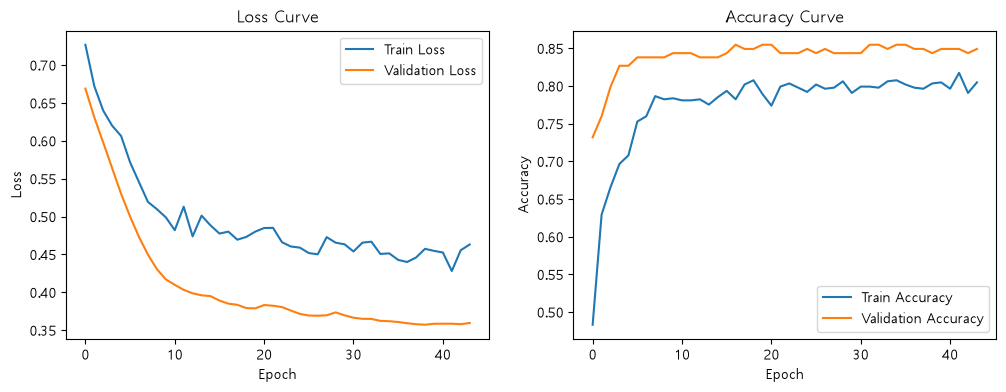

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [69]:
# 테스트 데이터 예측
y_pred = (model.predict(X_test_pca)>0.5).astype(int).flatten()
# sigmoid 출력이 0.5 이상이면 True(생존, 1), 0.5 미만이면 False(사망, 0)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


In [71]:
# 예측 결과 저장
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': y_pred
})
submission.to_csv('../dataset/submission.csv', index=False)
print("\n=== 예측 결과 상위 5개 ===")
print(submission.head())


=== 예측 결과 상위 5개 ===
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


### 타이타닉 생존자 예측 예제(LSTM)

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# 결측치를 처리하는데 사용
from sklearn.impute import SimpleImputer           
# 범주형 데이터를 숫자형 데이터로 변환하는 데 사용
from sklearn.preprocessing import LabelEncoder    
# feature importance와 유사 (LSTM에 사용)
import shap  

In [79]:
train_df = pd.read_csv("../dataset/train_titanic.csv")
test_df = pd.read_csv("../dataset/test_titanic.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
# 결측치 확인
print("Train 데이터 결측치 확인:")
print(train_df.isnull().sum())
print("\nTest 데이터 결측치 확인:")
print(test_df.isnull().sum())

Train 데이터 결측치 확인:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          688
Embarked         2
dtype: int64

Test 데이터 결측치 확인:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [81]:
# 불필요한 컬럼 제거(원핫인코딩 없이도 잘 작동하도록)
train_df = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [82]:
# Label Encoding(Sex 칼럼)
le = LabelEncoder()
train_df['Sex'] = le.fit_transform(train_df['Sex'])
test_df['Sex'] = le.transform(test_df['Sex'])
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [84]:
# Embarked 컬럼 정리(최빈값으로 채우기)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [85]:
# Label Encoding(Embarked 컬럼)
le_embarked = LabelEncoder()
train_df['Embarked'] = le_embarked.fit_transform(train_df['Embarked'])
test_df['Embarked'] = le_embarked.transform(test_df['Embarked'])

In [ ]:
# Age 컬럼 결측치 처리(평균)
imputer = SimpleImputer(strategy='mean')
train_df['Age'] = imputer.fit_transform(train_df[['Age']])
test_df['Age'] = imputer.transform(test_df[['Age']])

# Fare 컬럼 결측치 처리(평균)
# test 데이터에만 Fare 결측치 존재
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean())

In [87]:
# 전처리 후 데이터 확인
print("전처리 후 데이터 형태:")
print("Train 데이터:", train_df.shape)
print("Test 데이터:", test_df.shape)

전처리 후 데이터 형태:
Train 데이터: (891, 8)
Test 데이터: (418, 7)


In [88]:
# 데이터 컬럼 확인
print("\nTrain 데이터 컬럼:", train_df.columns.tolist())
print("Test 데이터 컬럼:", test_df.columns.tolist())


Train 데이터 컬럼: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Test 데이터 컬럼: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [89]:
# 스케일링 (MinMaxScaler)
scaler = MinMaxScaler()
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

In [90]:
n_features = X.shape[1]
print(f"피처 수: {n_features}")

피처 수: 7


In [91]:
X = scaler.fit_transform(X)
test_data = scaler.transform(test_df)

In [92]:
# 특성 이름 저장(SHAP 시각화에 사용)
feature_names = train_df.drop('Survived', axis=1).columns.tolist()

In [93]:
# train, validation set 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
# 데이터 형태 확인
print(f"X_train 형태(reshape 전): {X_train.shape}")
print(f"X_val 형태(reshape 전): {X_val.shape}")
print(f"test_data 형태(reshape 전): {test_data.shape}")

X_train 형태(reshape 전): (712, 7)
X_val 형태(reshape 전): (179, 7)
test_data 형태(reshape 전): (418, 7)


In [95]:
# LSTM 입력을 위한 reshape(samples, timesteps, features)
# 범주형 데이터에서는 일반적으로 timesteps = 1
X_train = X_train.reshape(X_train.shape[0], 1, n_features)
X_val = X_val.reshape(X_val.shape[0], 1, n_features)
test_data = test_data.reshape(test_data.shape[0], 1, n_features)

In [96]:
# reshape 후 형태 확인
print(f"X_train 형태(reshape 후): {X_train.shape}")
print(f"X_val 형태(reshape 후): {X_val.shape}")
print(f"test_data 형태(reshape 후): {test_data.shape}")

X_train 형태(reshape 후): (712, 1, 7)
X_val 형태(reshape 후): (179, 1, 7)
test_data 형태(reshape 후): (418, 1, 7)


In [112]:
# LSTM 모델 구축
model = Sequential()
model.add(LSTM(64, input_shape=(1, n_features), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
# 생존여부에 대한 이진 분류(1, 0)이므로 sigmoid 사용
model.add(Dense(1, activation='sigmoid'))

# binary_crossentropy : 이진 분류에 사용 (ex. 0, 1 등)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 

In [113]:
# 모델 구조 확인
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 1, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# Early Stopping - verbose=1로 설정하여 진행상황 확인
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    # 가장 좋은 성능을 보였던 모델의 가중치(weights)를 복원
    restore_best_weights=True,
    # 중단 시 메시지 출력
    verbose=1
)

In [115]:
# 모델 훈련 - verbose=1로 설정하여 진행상황 확인
epochs = 100
batch_size = 32

history = model.fit(
    X_train, 
    y_train,
    epochs = epochs,
    batch_size = batch_size,
    validation_data = (X_val, y_val),
    callbacks = [early_stopping],
    verbose = 1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6039 - loss: 0.6829 - val_accuracy: 0.5866 - val_loss: 0.6720
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6236 - loss: 0.6483 - val_accuracy: 0.5866 - val_loss: 0.6414
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6236 - loss: 0.6133 - val_accuracy: 0.5866 - val_loss: 0.6166
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6236 - loss: 0.5934 - val_accuracy: 0.5866 - val_loss: 0.5946
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6348 - loss: 0.5733 - val_accuracy: 0.6536 - val_loss: 0.5698
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6966 - loss: 0.5509 - val_accuracy: 0.7263 - val_loss: 0.5450
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7697 - loss: 0.5342 - val_accuracy: 0.7542 - val_loss: 0.5254
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7837 - loss: 0.5196 - val_accuracy: 0.7374

In [116]:
# 학습이 몇 번째 에폭에서 멈췄는지 확인
actual_epochs = len(history.history['loss'])
print(f"학습이 {actual_epochs}번째 에폭에서 완료되었습니다.")

학습이 59번째 에폭에서 완료되었습니다.


In [117]:
# 예측 및 평가
# Validation set 평가
y_pred_val_proba = model.predict(X_val, verbose=0)

# 0.5를 기준으로 분류, astype(int) : True는 1로, False는 0
y_pred_val = (y_pred_val_proba > 0.5).astype(int)

In [118]:
# 테스트 데이터 예측
y_pred_proba = model.predict(test_data, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

In [119]:
# ROC Curve 및 AUC 계산 (Validation set)
fpr, tpr, thresholds = roc_curve(y_val, y_pred_val_proba)
roc_auc = auc(fpr, tpr)

In [120]:
# Confusion Matrix (Validation set)
cm = confusion_matrix(y_val, y_pred_val)
print("Confusion Matrix (Validation Set):\n", cm)

Confusion Matrix (Validation Set):
 [[92 13]
 [23 51]]


In [121]:
# Classification Report (Validation set)
print("\nClassification Report (Validation Set):\n", classification_report(y_val, y_pred_val))


Classification Report (Validation Set):
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



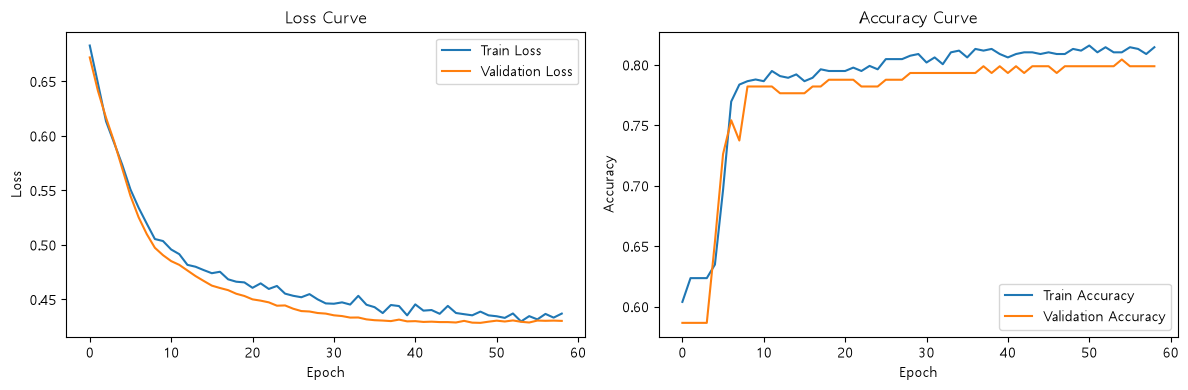

In [122]:
# 5. 결과 시각화 및 통계 분석

# 학습 곡선 시각화 (loss, accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

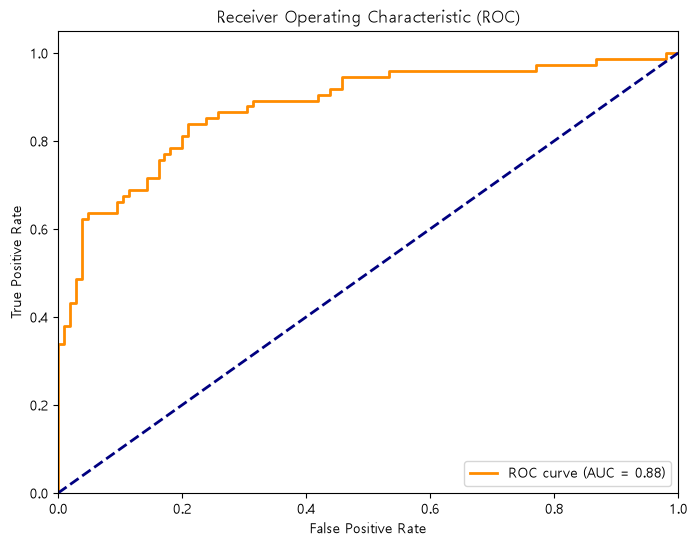

In [123]:
# ROC Curve 시각화 (Validation set)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

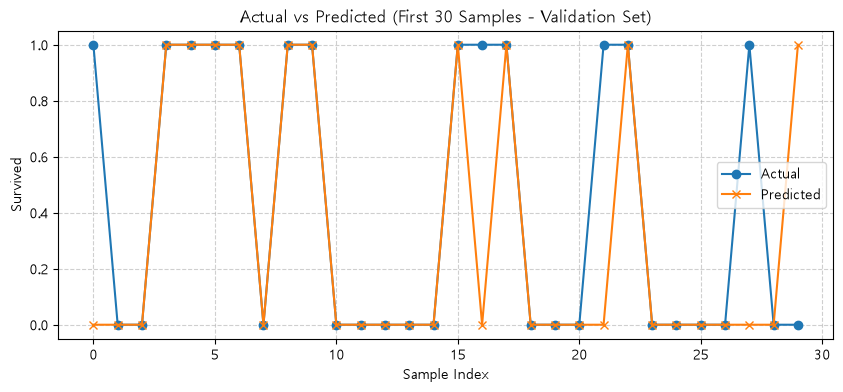

In [124]:
# 실제값 vs 예측값 시각화 (Validation set - 처음 30개 샘플)
plt.figure(figsize=(10, 4))
plt.plot(y_val[:30].values, label='Actual', marker='o')
plt.plot(y_pred_val[:30].flatten(), label='Predicted', marker='x')  # flatten() 추가
plt.title('Actual vs Predicted (First 30 Samples - Validation Set)')
plt.xlabel('Sample Index')
plt.ylabel('Survived')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)  # 그리드 추가
plt.show()

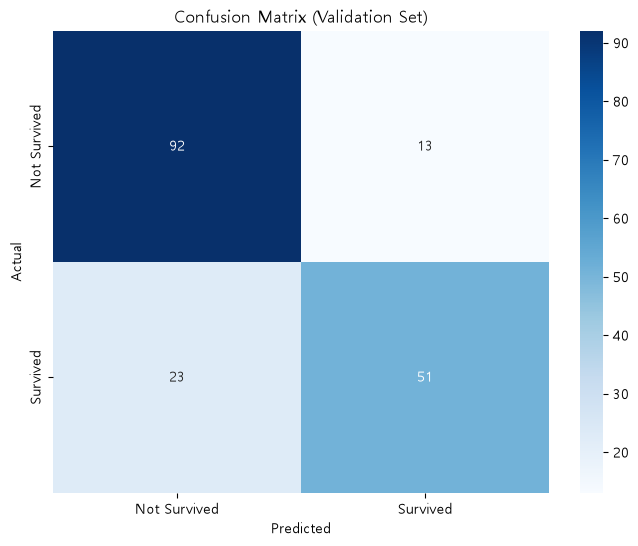

In [125]:
# Confusion Matrix 시각화 (Validation set)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [127]:
# 6. 데이터셋 로드
# test_titanic.csv에서 직접 PassengerId 가져오기
original_test_df = pd.read_csv("../dataset/test_titanic.csv")
passenger_ids = original_test_df['PassengerId']

In [128]:
# 예측 결과와 PassengerId를 합쳐 새로운 DataFrame 생성
forecast_results = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': y_pred.flatten()  # flatten()으로 1차원 배열로 변환
})

### 비지도학습 클러스터링 예제(k-means)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [129]:
dataset = pd.read_csv('../dataset/KMeansData.csv')
dataset[:5]

,hour,score
0,7.33,73
1,3.71,55
2,3.43,55
3,3.06,89
4,3.33,79


In [130]:
X = dataset.iloc[:,:].values
X[:5]

array([[ 7.33, 73.  ],
       [ 3.71, 55.  ],
       [ 3.43, 55.  ],
       [ 3.06, 89.  ],
       [ 3.33, 79.  ]])

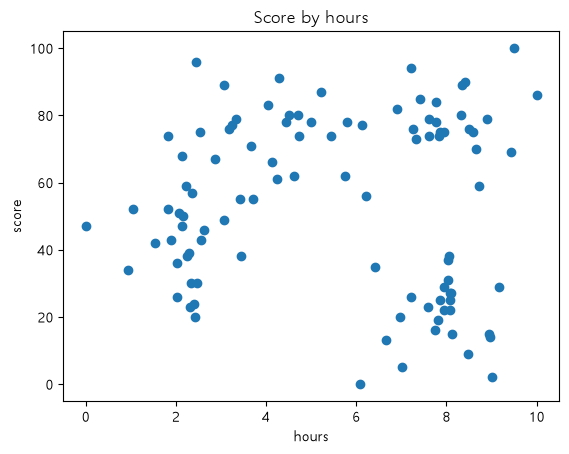

In [131]:
plt.scatter(X[:,0], X[:, 1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

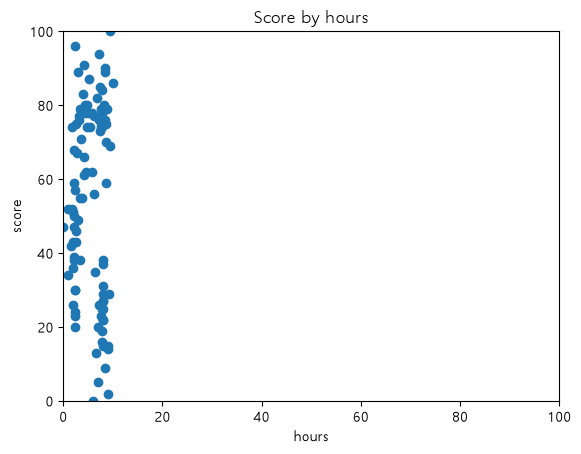

In [132]:
plt.scatter(X[:,0], X[:, 1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.xlim(0, 100)
plt.ylabel('score')
plt.ylim(0, 100)
plt.show()

In [133]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
X[:5]

array([[ 0.68729921,  0.73538376],
       [-0.66687438,  0.04198891],
       [-0.77161709,  0.04198891],
       [-0.9100271 ,  1.35173473],
       [-0.8090252 ,  0.96651537]])

In [135]:
plt.rcParams['axes.unicode_minus'] = False

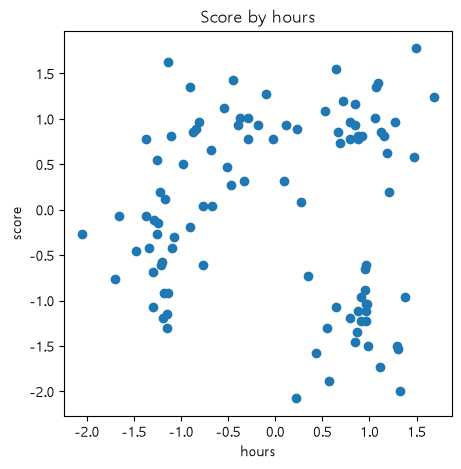

In [136]:
plt.figure(figsize =(5, 5))
plt.scatter(X[:,0], X[:, 1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

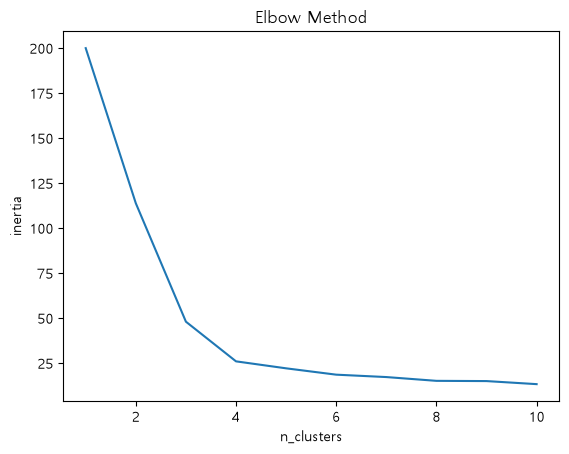

In [138]:
from sklearn.cluster import KMeans

inertia_list = []
for i in range(1, 11):
    kmaens = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmaens.fit(X)
    inertia_list.append(kmaens.inertia_)
plt.plot(range(1, 11), inertia_list)
plt.title('Elbow Method')
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.show()

In [139]:
K=4
kmeans = KMeans(n_clusters=K, random_state=0)
y_kmeans = kmeans.fit_predict(X)

y_kmeans

array([1, 0, 3, 0, 0, 2, 2, 0, 1, 0, 0, 3, 2, 3, 3, 0, 2, 1, 3, 0, 2, 0,
       3, 2, 1, 1, 3, 3, 3, 3, 2, 2, 3, 0, 1, 1, 3, 0, 0, 0, 3, 2, 1, 3,
       3, 1, 2, 0, 2, 2, 1, 0, 2, 2, 0, 0, 0, 0, 3, 2, 2, 1, 1, 1, 1, 2,
       2, 0, 2, 1, 3, 1, 1, 1, 3, 3, 3, 3, 0, 1, 2, 1, 2, 2, 1, 0, 3, 2,
       1, 3, 0, 2, 0, 1, 3, 0, 1, 0, 2, 3], dtype=int32)

In [140]:
centers = kmeans.cluster_centers_
centers

array([[-0.54299598,  0.79316666],
       [ 0.96910697,  0.97133061],
       [ 0.8837666 , -1.26929779],
       [-1.24939347, -0.48807293]])

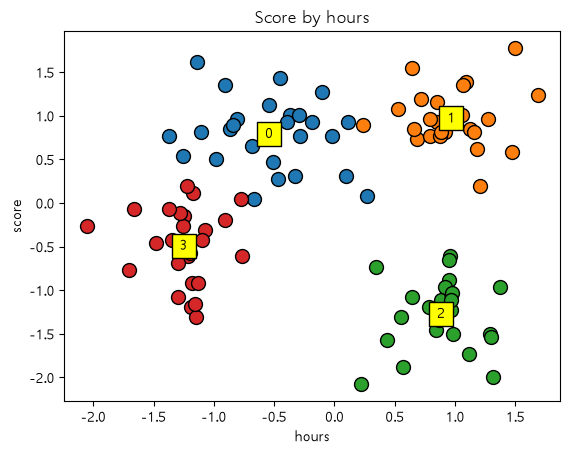

In [141]:
for cluster in range(K):
    plt.scatter(X[y_kmeans == cluster, 0], X[y_kmeans == cluster, 1], s=100, edgecolor='black')
    plt.scatter(centers[cluster, 0], centers[cluster, 1], s=300, edgecolor='black', color='yellow', marker='s')
    plt.text(centers[cluster, 0], centers[cluster, 1], cluster, va='center', ha='center')

plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

In [142]:
X_org = sc.inverse_transform(X)
X_org[:5]

array([[ 7.33, 73.  ],
       [ 3.71, 55.  ],
       [ 3.43, 55.  ],
       [ 3.06, 89.  ],
       [ 3.33, 79.  ]])

In [143]:
centers_org = sc.inverse_transform(centers)
centers_org

array([[ 4.04115385, 74.5       ],
       [ 8.08333333, 79.125     ],
       [ 7.8552    , 20.96      ],
       [ 2.1528    , 41.24      ]])

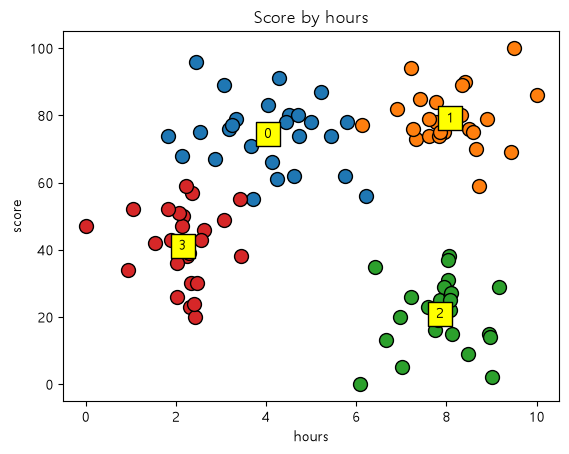

In [144]:
for cluster in range(K):
    plt.scatter(X_org[y_kmeans == cluster, 0], X_org[y_kmeans == cluster, 1], s=100, edgecolor='black')
    plt.scatter(centers_org[cluster, 0], centers_org[cluster, 1], s=300, edgecolor='black', color='yellow', marker='s')
    plt.text(centers_org[cluster, 0], centers_org[cluster, 1], cluster, va='center', ha='center')

plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()